# CellMESH Comprehensive Notebook

覆盖 Metabolite Availability、Sensor/Receiver Score 和完整 Cell MESH 通讯分数。默认使用包内 `cellmesh/data/test_single_cell.h5ad`、`Enzyme_new.csv`、`Interaction1.0.csv`。如果当前实现与规范公式不同，本 notebook 会按实际可用字段做兼容展示。

In [26]:
from pathlib import Path
import inspect
import numpy as np
import pandas as pd
from scipy import sparse
from scipy.stats import gmean
import matplotlib.pyplot as plt

import cellmesh
from cellmesh import run_cell_mesh, load_cell_mesh_database, compute_metabolite_availability, read_anndata, read_example_data
from cellmesh.core import _enzyme_prior_to_availability_reactions, _confidence_tier
from cellmesh.preprocess import (
    robust_minmax,
    _parse_reaction_table,
    _get_reaction_gene_sets,
    _compute_reaction_scores,
    _compute_PCE_matrices,
    _normalize_PCE,
)
from cellmesh.scoring import sigmoid, zscore_by_gene

try:
    import seaborn as sns
except ImportError:
    sns = None

%matplotlib inline
pd.set_option('display.max_columns', 80)
print('cellmesh', cellmesh.__version__)

cellmesh 0.4.0


In [2]:
PACKAGE_ROOT = Path.cwd().parent if Path.cwd().name == 'examples' else Path.cwd()
DATA_DIR = PACKAGE_ROOT / 'cellmesh' / 'data'
h5ad_path = DATA_DIR / 'test_single_cell.h5ad'
enzyme_path = DATA_DIR / 'Enzyme_new.csv'
interaction_path = DATA_DIR / 'Interaction1.0.csv'

if not enzyme_path.exists(): enzyme_path = DATA_DIR / 'enzyme_test.csv'
if not interaction_path.exists(): interaction_path = DATA_DIR / 'interaction_test.csv'

print('h5ad_path =', h5ad_path)
print('enzyme_path =', enzyme_path)
print('interaction_path =', interaction_path)

h5ad_path = /home/qsong/.openclaw/workspace/developer/cell_mesh_pkg/cellmesh/data/test_single_cell.h5ad
enzyme_path = /home/qsong/.openclaw/workspace/developer/cell_mesh_pkg/cellmesh/data/Enzyme_new.csv
interaction_path = /home/qsong/.openclaw/workspace/developer/cell_mesh_pkg/cellmesh/data/Interaction1.0.csv


In [3]:
if h5ad_path.exists():
    adata = read_anndata(h5ad_path, mode='h5ad')
else:
    adata = read_example_data('small')

if '_index' in adata.var.columns:
    adata.var_names = adata.var['_index'].astype(str)

enzyme_df, interaction_df = load_cell_mesh_database(str(enzyme_path), str(interaction_path))
reaction_table = _enzyme_prior_to_availability_reactions(enzyme_df)

print(adata)
display(enzyme_df.head())
display(interaction_df.head())

AnnData object with n_obs × n_vars = 500 × 558
    obs: '__categories', 'cell_name', 'cell_type'
    var: '_index'


,metabolite,hmdb_id,gene,role,weight,evidence_level,source,reaction
0,Uracil,HMDB0000300,PNP,production,1.0,Enzyme,packaged_enzyme_test,Deoxyuridine + Phosphate → Uracil + Deoxyribos...
1,Uracil,HMDB0000300,TYMP,production,1.0,Enzyme,packaged_enzyme_test,Deoxyuridine + Phosphate → Uracil + Deoxyribos...
2,Uracil,HMDB0000300,DPYD,production,1.0,Unknown,packaged_enzyme_test,Dihydrouracil + NADP → Uracil + NADPH
3,Uracil,HMDB0000300,DPYD,production,1.0,Unknown,packaged_enzyme_test,Dihydrouracil + NADP → Uracil + NADPH + Hydrog...
4,Uracil,HMDB0000300,UPP1,production,1.0,Enzyme,packaged_enzyme_test,Uridine + Phosphate → Uracil + Ribose 1-phosphate


,metabolite,hmdb_id,sensor_gene,sensor_type,weight,evidence_level,source,protein_name,reference
0,prostaglandin A1(1-),HMDB0002656,SLCO2A1,Transporter,1.0,Transporter,Recon2,SO2A1_HUMAN,NaN
1,Spermidine,HMDB0001257,SLC22A3,Transporter,1.0,Transporter,NaN,S22A3_HUMAN,10.1021/mp400024d
2,Spermine,HMDB0001256,SLC22A2,Transporter,1.0,Transporter,NaN,S22A1_HUMAN,10.1021/mp400024d
3,Spermidine,HMDB0001257,SLC22A2,Transporter,1.0,Transporter,NaN,S22A1_HUMAN,10.1021/mp400024d
4,Spermine,HMDB0001256,SLC22A1,Transporter,1.0,Transporter,"[MEBOCOST, MRCLinkdb]",S22A1_HUMAN,10.1074/jbc.271.51.32599


## 3.1 Metabolite Availability 计算

In [4]:
# TC-A1
avail = compute_metabolite_availability(adata, reaction_table, celltype_col='cell_type', return_intermediates=True)
availability = avail['availability']
print('availability shape:', availability.shape)
print('range:', float(np.nanmin(availability.values)), float(np.nanmax(availability.values)))
print('pseudobulk shape:', avail['pseudobulk'].shape)
assert not availability.empty
assert availability.values.min() >= 0 and availability.values.max() <= 1
assert avail['metadata']['has_product'].all()
print('PASS TC-A1')

availability shape: (4, 8)
range: 0.0 0.8049844643234919
pseudobulk shape: (8, 558)
PASS TC-A1


In [22]:
adata.X[:5, :5].toarray()

array([[1.0129967 , 1.7133949 , 0.        , 1.7073652 , 0.        ],
       [1.8078864 , 2.4045339 , 2.0588615 , 2.7371469 , 0.        ],
       [0.        , 2.7409782 , 2.5595398 , 1.9687657 , 1.6943386 ],
       [0.7673623 , 0.        , 2.5512893 , 0.        , 0.        ],
       [2.677824  , 2.2181773 , 0.13222213, 0.        , 0.        ]],
      dtype=float32)

In [23]:
avail['pseudobulk']

_index,AACS,AARS,AARS2,ABCA1,ABCB1,ABCC8,ACACA,ACACB,ACLY,ACOT2,ACSBG1,ACSBG2,ACSL1,ACSL3,ACSL4,ACSL5,ACSL6,ACSM1,ACSM2A,ACSM2B,ACSM3,ACSM4,ACSM5,ACSM6,ACSS1,ACSS2,ACSS3,ACVR1,ACVR1B,ACVRL1,ADCY1,ADCY10,ADCY2,ADCY3,ADCY4,ADCY5,ADCY6,ADCY7,ADCY8,ADCY9,...,UBE2H,UBE2I,UBE2J1,UBE2J2,UBE2K,UBE2L3,UBE2L6,UBE2M,UBE2N,UBE2O,UBE2Q1,UBE2Q2,UBE2QL1,UBE2R2,UBE2S,UBE2T,UBE2U,UBE2W,UBE2Z,UCK1,UCK2,UCKL1,UEVLD,UPP1,UPP2,UPRT,VARS,VARS2,VCP,VPS4A,VPS4B,WARS,WARS2,WBSCR22,WRN,XYLB,YARS,YARS2,YTHDC2,ZNRD1
Endothelial_cells,1.101942,1.001491,1.038585,1.186432,1.114006,1.250667,1.218614,0.976613,1.337975,0.964925,0.971952,1.328940,1.060412,1.407996,1.250702,1.146352,1.335929,1.066704,1.002731,1.199725,1.084897,1.382584,1.296398,1.135298,1.293390,1.370660,0.999148,1.229040,1.163822,1.102450,0.935314,1.101823,1.338852,1.066281,1.057236,1.120129,1.042273,1.273236,1.100389,1.127844,...,1.102320,1.061752,1.057664,1.138281,1.127851,1.130637,1.004661,1.013435,1.094716,1.090170,0.963262,1.329051,1.168859,1.200111,0.988641,1.167498,1.190229,1.112677,1.161550,1.212360,1.184276,1.069230,1.292963,1.294973,0.939706,1.153087,0.952915,1.120038,1.239669,1.255950,1.298481,1.341907,1.051726,1.462039,1.348772,1.037421,1.207134,1.160364,1.152380,1.081738
Epithelial_cells,1.224329,1.316371,1.104500,1.313209,1.120272,1.261486,1.259367,1.181394,1.047855,1.312814,1.123968,1.284778,1.161067,1.349668,1.117223,1.021485,1.070086,1.082622,1.276826,1.274848,1.284949,1.181410,1.127750,1.037599,1.294326,1.202553,1.250364,1.198706,1.319090,1.188477,1.090146,1.100410,1.073632,1.317708,1.236228,1.073406,1.110335,1.029669,1.097610,1.392174,...,1.176593,0.876607,1.094282,1.216972,1.283130,1.337120,1.222877,1.076571,1.281864,1.211373,1.072892,1.338411,1.248276,1.117556,1.412729,1.128207,1.246262,1.210022,1.172146,1.228476,1.007089,1.154595,1.389408,1.310131,1.099035,1.049265,1.154226,1.137552,1.278157,1.093321,1.241468,1.451923,1.256758,1.069538,1.079992,1.043000,1.290622,1.116897,1.088998,0.974285
T_cells,1.076266,1.295392,1.386993,1.214242,1.297063,1.153865,0.983886,1.058255,1.280904,1.186275,1.054674,1.211844,1.129581,1.117692,1.273570,1.051950,1.212291,1.224939,1.233563,1.161216,1.190953,1.302710,1.082273,1.177048,1.136311,1.169629,1.191613,1.112701,1.290699,1.235255,1.152014,1.171128,1.165225,1.100210,0.975606,1.105819,1.106982,0.985814,1.013176,1.221664,...,1.259738,1.390242,1.201270,1.109717,1.289700,1.258439,0.996655,1.248668,1.247569,1.042709,1.309495,1.172114,1.240034,1.079117,1.116991,1.125824,1.494423,0.792083,1.079707,1.109121,1.139253,1.041288,1.404397,1.061588,1.197330,1.166246,1.083570,0.895717,1.273345,1.168138,1.100760,1.304644,1.193030,0.898520,1.150450,1.217826,1.386604,1.319233,1.013929,1.107588
Macrophages,1.390305,1.048854,1.188173,1.224861,1.132892,1.389962,0.962117,1.294589,1.290153,0.951673,1.087569,1.181210,1.216010,1.094025,1.135538,0.897306,1.134142,1.002265,0.893614,0.976875,1.133574,1.098952,1.439168,1.136759,0.801517,1.107324,0.965527,1.094135,1.281177,1.069094,0.949763,1.288863,0.946248,1.038397,0.816387,1.029347,1.143653,1.269700,1.105839,0.994007,...,1.208093,1.207007,1.277164,1.063382,1.206445,0.875943,1.077711,1.290114,1.132009,1.152485,1.330946,1.384432,1.167973,1.030567,0.758964,1.068525,1.061586,1.099375,1.215525,0.927004,1.068982,1.178710,1.133062,1.211150,1.094015,1.303017,0.919485,1.127179,0.909401,1.154670,1.100616,1.467603,1.061935,1.302321,1.187344,1.247690,1.350348,1.006471,1.319424,1.409064
NK_cells,1.429839,0.979742,1.106288,1.188522,1.100690,1.178359,1.485445,1.197736,1.242582,0.800506,1.116963,0.925463,1.222140,0.947716,1.014726,1.340141,1.234837,1.344219,1.397893,1.144453,1.327695,0.902321,1.114446,0.984028,1.059692,1.272834,1.271070,1.060190,1.065134,1.428617,1.071225,1.248784,1.485413,1.098450,1.036570,1.042169,1.112328,0.991686,1.165821,1.315192,...,1.321793,0.932739,1.396156,1.194652,1.217795,0.948129,1.262424,1.196111,1.004132,1.028395,1.484861,1.221377,1.080317,1.172765,1.180623,1.424097,1.399675,1.133534,1.176300,1.434697,1.

### 新增测试 1：pseudobulk 聚合计算前后一致性

这里从单细胞表达矩阵手动按 `cell_type` 聚合平均值，并与 `compute_metabolite_availability()` 返回的 `pseudobulk` 对比。下方同时展示聚合前的部分单细胞表达、手动聚合后的结果，以及函数内部返回结果。


In [24]:
# 新增测试 1: pseudobulk aggregation consistency
raw_X = adata.X.toarray() if hasattr(adata.X, 'toarray') else np.asarray(adata.X)
raw_expr = pd.DataFrame(raw_X, index=adata.obs_names, columns=adata.var_names.astype(str))
labels = adata.obs['cell_type'].astype(str)
valid_groups = labels.value_counts()[lambda s: s >= 1].index.tolist()

manual_pseudobulk = pd.DataFrame(
    [raw_expr.loc[labels.values == group].mean(axis=0).values for group in valid_groups],
    index=valid_groups,
    columns=raw_expr.columns,
)
internal_pseudobulk = avail['pseudobulk']
manual_pseudobulk = manual_pseudobulk.loc[internal_pseudobulk.index, internal_pseudobulk.columns]

print('聚合前：单细胞表达矩阵片段')
display(raw_expr.iloc[:8, :8].assign(cell_type=labels.iloc[:8].values))
print('手动聚合后：pseudobulk 片段')
display(manual_pseudobulk.iloc[:5, :8])
print('函数返回：pseudobulk 片段')
display(internal_pseudobulk.iloc[:5, :8])
print('手动聚合 vs 函数返回：差值片段')
display((manual_pseudobulk - internal_pseudobulk).abs().iloc[:5, :8])

pd.testing.assert_frame_equal(internal_pseudobulk, manual_pseudobulk, atol=1e-10, rtol=0, check_dtype=False)
print('max abs diff:', float((manual_pseudobulk - internal_pseudobulk).abs().to_numpy().max()))
print('PASS pseudobulk aggregation consistency')


聚合前：单细胞表达矩阵片段


_index,AACS,AARS,AARS2,ABCA1,ABCB1,ABCC8,ACACA,ACACB,cell_type
0,1.012997,1.713395,0.000000,1.707365,0.000000,0.000000,1.360774,0.000000,Dendritic_cells
1,1.807886,2.404534,2.058861,2.737147,0.000000,1.949197,2.417361,0.000000,Endothelial_cells
2,0.000000,2.740978,2.559540,1.968766,1.694339,1.524155,0.000000,0.000000,Fibroblasts
3,0.767362,0.000000,2.551289,0.000000,0.000000,2.746219,0.000000,0.000000,Dendritic_cells
4,2.677824,2.218177,0.132222,0.000000,0.000000,2.203701,0.000000,2.053877,Macrophages
5,0.000000,2.408785,2.191399,2.407468,1.178137,2.727814,0.000000,2.481003,Epithelial_cells
6,2.562223,2.383308,0.000000,2.553860,2.589561,0.545141,2.042943,2.033552,Fibroblasts
7,0.000000,0.000000,2.256730,1.729905,0.000000,2.632275,2.232501,2.739735,Fibroblasts


手动聚合后：pseudobulk 片段


_index,AACS,AARS,AARS2,ABCA1,ABCB1,ABCC8,ACACA,ACACB
Endothelial_cells,1.101942,1.001491,1.038585,1.186432,1.114006,1.250667,1.218614,0.976613
Epithelial_cells,1.224329,1.316371,1.104500,1.313209,1.120272,1.261486,1.259367,1.181394
T_cells,1.076266,1.295392,1.386993,1.214242,1.297063,1.153865,0.983886,1.058255
Macrophages,1.390305,1.048854,1.188173,1.224861,1.132892,1.389962,0.962117,1.294589
NK_cells,1.429839,0.979742,1.106288,1.188522,1.100690,1.178359,1.485445,1.197736


函数返回：pseudobulk 片段


_index,AACS,AARS,AARS2,ABCA1,ABCB1,ABCC8,ACACA,ACACB
Endothelial_cells,1.101942,1.001491,1.038585,1.186432,1.114006,1.250667,1.218614,0.976613
Epithelial_cells,1.224329,1.316371,1.104500,1.313209,1.120272,1.261486,1.259367,1.181394
T_cells,1.076266,1.295392,1.386993,1.214242,1.297063,1.153865,0.983886,1.058255
Macrophages,1.390305,1.048854,1.188173,1.224861,1.132892,1.389962,0.962117,1.294589
NK_cells,1.429839,0.979742,1.106288,1.188522,1.100690,1.178359,1.485445,1.197736


手动聚合 vs 函数返回：差值片段


_index,AACS,AARS,AARS2,ABCA1,ABCB1,ABCC8,ACACA,ACACB
Endothelial_cells,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Epithelial_cells,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
T_cells,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Macrophages,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NK_cells,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


max abs diff: 0.0
PASS pseudobulk aggregation consistency


In [5]:
# TC-A2: availability formula consistency, with before/after data display
formula_inputs = pd.concat(
    {
        'P_norm': avail['P_norm'].stack(),
        'C_norm': avail['C_norm'].stack(),
        'E_norm': avail['E_norm'].stack(),
    },
    axis=1,
).reset_index().rename(columns={'level_2': 'cell_type'})
formula_inputs['manual_availability'] = (
    formula_inputs['P_norm']
    * ((1 - formula_inputs['C_norm']) ** 0.5)
    * (0.8 + 0.2 * formula_inputs['E_norm'])
).clip(0, 1)
observed_long = availability.stack().reset_index(name='function_availability').rename(columns={'level_2': 'cell_type'})
formula_check = formula_inputs.merge(observed_long, on=['metabolite', 'hmdb_id', 'cell_type'])
formula_check['abs_diff'] = (formula_check['manual_availability'] - formula_check['function_availability']).abs()

print('计算前输入片段：P_norm / C_norm / E_norm')
display(formula_inputs.head(10))
print('计算后对比片段：manual_availability vs function_availability')
display(formula_check.head(10))

expected = avail['P_norm'] * ((1 - avail['C_norm']) ** 0.5) * (0.8 + 0.2 * avail['E_norm'])
pd.testing.assert_frame_equal(availability, expected.clip(0, 1), atol=1e-10, rtol=0)
print('max abs diff:', float(formula_check['abs_diff'].max()))
print('PASS TC-A2')


max abs diff: 0.0
PASS TC-A2


In [27]:
# TC-A2-extra: from pseudobulk to P/C/E, then normalized P/C/E, with before/after display
# 选取若干个 P 总量最高的代谢物，展示 availability 公式上游的完整中间过程。
selected_mets = avail['P'].sum(axis=1).sort_values(ascending=False).head(3).index
selected_keys = {
    f"{met}|{str(hmdb) if pd.notna(hmdb) else 'nan'}"
    for met, hmdb in selected_mets
}

parsed_reactions_manual = _parse_reaction_table(reaction_table)
reaction_genes_manual = _get_reaction_gene_sets(parsed_reactions_manual)

def _met_key(met, hmdb):
    return f"{met}|{str(hmdb) if pd.notna(hmdb) else 'nan'}"

def _reaction_id(row):
    return f"{row['metabolite']}|{str(row['hmdb_id']) if pd.notna(row['hmdb_id']) else 'nan'}|{row['reaction']}|{row['direction']}"

related_mask = reaction_genes_manual.apply(
    lambda row: _met_key(row['metabolite'], row['hmdb_id']) in selected_keys,
    axis=1,
)
related_reaction_genes = reaction_genes_manual.loc[related_mask].copy()
related_reaction_genes['reaction_id'] = related_reaction_genes.apply(_reaction_id, axis=1)
related_reaction_ids = related_reaction_genes['reaction_id'].tolist()
related_genes = sorted({
    gene
    for genes in related_reaction_genes['genes']
    for gene in genes
    if gene in avail['pseudobulk'].columns
})

# 1) pseudobulk -> reaction score：每个 reaction 的基因表达加权几何均值
manual_reaction_scores = _compute_reaction_scores(avail['pseudobulk'], reaction_genes_manual)

# 2) reaction score -> raw P/C/E：按 product/substrate/exporter 方向累加到代谢物层面
manual_pce = _compute_PCE_matrices(manual_reaction_scores, reaction_genes_manual)
manual_P = manual_pce['P'].reindex(avail['P'].index, fill_value=0.0)
manual_C = manual_pce['C'].reindex(avail['C'].index, fill_value=0.0)
manual_E = manual_pce['E'].reindex(avail['E'].index, fill_value=0.0)

# 3) raw P/C/E -> normalized P/C/E：逐代谢物跨细胞类型做 robust min-max；缺失 C/E 使用默认值
manual_norm = _normalize_PCE(
    manual_P,
    manual_C,
    manual_E,
    reaction_genes_manual,
    lower=5,
    upper=95,
    missing_C_norm=0.2,
    missing_E_norm=0.5,
)

print('选取的代谢物：')
display(pd.DataFrame(list(selected_mets), columns=['metabolite', 'hmdb_id']))
print('相关 reaction-gene 映射（用于从 pseudobulk 计算 reaction score）：')
display(related_reaction_genes[['metabolite', 'hmdb_id', 'reaction', 'direction', 'genes', 'weights']].head(12))

print('计算前：pseudobulk 中相关基因表达片段')
display(avail['pseudobulk'].loc[:, related_genes[:10]].head() if related_genes else avail['pseudobulk'].iloc[:, :10].head())
print('pseudobulk 计算后：相关 reaction score 片段')
display(manual_reaction_scores.loc[related_reaction_ids].head(12))

raw_pce_long = pd.concat(
    {
        'P_raw': manual_P.loc[selected_mets].stack(),
        'C_raw': manual_C.loc[selected_mets].stack(),
        'E_raw': manual_E.loc[selected_mets].stack(),
    },
    axis=1,
).reset_index().rename(columns={'level_2': 'cell_type'})
norm_pce_long = pd.concat(
    {
        'P_norm': manual_norm['P_norm'].loc[selected_mets].stack(),
        'C_norm': manual_norm['C_norm'].loc[selected_mets].stack(),
        'E_norm': manual_norm['E_norm'].loc[selected_mets].stack(),
    },
    axis=1,
).reset_index().rename(columns={'level_2': 'cell_type'})
pce_before_after = raw_pce_long.merge(norm_pce_long, on=['metabolite', 'hmdb_id', 'cell_type'])
pce_before_after['manual_availability_from_norm'] = (
    pce_before_after['P_norm']
    * ((1 - pce_before_after['C_norm']) ** 0.5)
    * (0.8 + 0.2 * pce_before_after['E_norm'])
).clip(0, 1)
function_availability_selected = availability.loc[selected_mets].stack().reset_index(name='function_availability').rename(columns={'level_2': 'cell_type'})
pce_before_after = pce_before_after.merge(
    function_availability_selected,
    on=['metabolite', 'hmdb_id', 'cell_type'],
)
pce_before_after['abs_diff'] = (
    pce_before_after['manual_availability_from_norm']
    - pce_before_after['function_availability']
).abs()

print('标准化前后：raw P/C/E -> P_norm/C_norm/E_norm，并继续计算 availability')
display(pce_before_after.head(15))

# 与 compute_metabolite_availability() 返回的中间结果和最终结果保持一致。
pd.testing.assert_frame_equal(manual_P.loc[selected_mets], avail['P'].loc[selected_mets], atol=1e-10, rtol=0, check_dtype=False)
pd.testing.assert_frame_equal(manual_C.loc[selected_mets], avail['C'].loc[selected_mets], atol=1e-10, rtol=0, check_dtype=False)
pd.testing.assert_frame_equal(manual_E.loc[selected_mets], avail['E'].loc[selected_mets], atol=1e-10, rtol=0, check_dtype=False)
pd.testing.assert_frame_equal(manual_norm['P_norm'].loc[selected_mets], avail['P_norm'].loc[selected_mets], atol=1e-10, rtol=0, check_dtype=False)
pd.testing.assert_frame_equal(manual_norm['C_norm'].loc[selected_mets], avail['C_norm'].loc[selected_mets], atol=1e-10, rtol=0, check_dtype=False)
pd.testing.assert_frame_equal(manual_norm['E_norm'].loc[selected_mets], avail['E_norm'].loc[selected_mets], atol=1e-10, rtol=0, check_dtype=False)
print('max abs diff:', float(pce_before_after['abs_diff'].max()))
print('PASS TC-A2 pseudobulk -> PCE -> normalized PCE display')


选取的代谢物：


,metabolite,hmdb_id
0,Adenosine triphosphate,HMDB0000538
1,Uracil,HMDB0000300
2,oxalate(2-),HMDB0002329


相关 reaction-gene 映射（用于从 pseudobulk 计算 reaction score）：


,metabolite,hmdb_id,reaction,direction,genes,weights
0,Uracil,HMDB0000300,Deoxyuridine + Phosphate → Uracil + Deoxyribos...,product,"[PNP, TYMP]","[1.0, 1.0]"
1,Uracil,HMDB0000300,Dihydrouracil + NADP → Uracil + NADPH,product,[DPYD],[1.0]
2,Uracil,HMDB0000300,Dihydrouracil + NADP → Uracil + NADPH + Hydrog...,product,[DPYD],[1.0]
3,Uracil,HMDB0000300,Uridine + Phosphate → Uracil + Ribose 1-phosphate,product,"[UPP1, UPP2]","[1.0, 1.0]"
4,Uracil,HMDB0000300,Uridine 5&#39;-monophosphate + Pyrophosphate →...,product,[UPRT],[1.0]
14,oxalate(2-),HMDB0002329,Water + Nicotinamide adenine dinucleotide + gl...,product,"[LDHA, LDHAL6B, LDHB, LDHC, LDHD, UEVLD]","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0]"
15,oxalate(2-),HMDB0002329,O2 + Water + glyoxylate → proton + Hydrogen pe...,product,"[HAO1, HAO2]","[1.0, 1.0]"
17,Adenosine triphosphate,HMDB0000538,"17alpha,20alpha-Dihydroxypregn-4-en-3-one + Ad...",substrate,[SLC27A5],[1.0]
18,Adenosine triphosphate,HMDB0000538,3-Hydroxypropionyl-CoA + Phosphate + ADP → Hyd...,product,[HIBCH],[1.0]
19,Adenosine triphosphate,HMDB0000538,5-Fluorouridine + Adenosine triphosphate → 5-F...,substrate,"[UCK1, UCK2, UCKL1]","[1.0, 1.0, 1.0]"


计算前：pseudobulk 中相关基因表达片段


...

pseudobulk 计算后：相关 reaction score 片段


,Endothelial_cells,Epithelial_cells,T_cells,Macrophages,NK_cells,Dendritic_cells,Fibroblasts,B_cells
Uracil|HMDB0000300|Deoxyuridine + Phosphate → Uracil + Deoxyribose 1-phosphate|product,1.118330,1.142345,1.340738,1.284749,0.956685,1.101869,1.148792,1.257785
Uracil|HMDB0000300|Dihydrouracil + NADP → Uracil + NADPH|product,1.014407,0.940365,1.123077,1.239813,1.005779,1.017737,1.042701,1.216562
Uracil|HMDB0000300|Dihydrouracil + NADP → Uracil + NADPH + Hydrogen Ion|product,1.014407,0.940365,1.123077,1.239813,1.005779,1.017737,1.042701,1.216562
Uracil|HMDB0000300|Uridine + Phosphate → Uracil + Ribose 1-phosphate|product,1.109875,1.202055,1.128377,1.151785,1.268806,1.252454,1.395413,1.129093
Uracil|HMDB0000300|Uridine 5&#39;-monophosphate + Pyrophosphate → Uracil + Phosphoribosyl pyrophosphate|product,1.153087,1.049265,1.166246,1.303017,1.212000,1.322329,0.944079,1.653332
oxalate(2-)|HMDB0002329|Water + Nicotinamide adenine dinucleotide + glyoxylate → proton + Nicotinamide adenine dinucleotide - reduced + oxalate(2-)|product,1.118203,1.292217,1.201103,1.155530,1.239564,1.144431,1.240258,1.164845
oxalate(2-)|HMDB0002329|O2 + Water + glyoxylate → proton + Hydrogen peroxide + oxalate(2-)|product,1.125853,1.152117,1.030613,1.200145,1.135189,1.089681,1.122865,1.209996
"Adenosine triphosphate|HMDB0000538|17alpha,20alpha-Dihydroxypregn-4-en-3-one + Adenosine triphosphate + Coenzyme A → (25R)-3alpha,7alpha-Dihydroxy-5beta-cholestanoyl-CoA + Adenosine monophosphate + Pyrophosphate|substrate",1.139079,1.169885,1.150115,1.256416,1.107687,1.217782,1.117724,0.854479
Adenosine triphosphate|HMDB0000538|3-Hydroxypropionyl-CoA + Phosphate + ADP → Hydroxypropionic acid + Coenzyme A + Adenosine triphosphate|product,1.130348,1.306809,1.093164,0.989998,1.202406,1.466985,1.111757,1.418905
Adenosine triphosphate|HMDB0000538|5-Fluorouridine + Adenosine triphosphate → 5-Fluorouridine monophosphate + ADP|substrate,1.154388,1.128041,1.096152,1.055636,1.221528,1.149580,1.246333,1.207813


标准化前后：raw P/C/E -> P_norm/C_norm/E_norm，并继续计算 availability


,metabolite,hmdb_id,cell_type,P_raw,C_raw,E_raw,P_norm,C_norm,E_norm,manual_availability_from_norm,function_availability,abs_diff
0,Adenosine triphosphate,HMDB0000538,Endothelial_cells,10.709058,292.946972,0.0,0.819530,0.444297,0.5,0.549830,0.549830,0.0
1,Adenosine triphosphate,HMDB0000538,Epithelial_cells,10.808430,293.048582,0.0,0.937300,0.457051,0.5,0.621585,0.621585,0.0
2,Adenosine triphosphate,HMDB0000538,T_cells,10.592166,295.598831,0.0,0.680998,0.777136,0.5,0.289340,0.289340,0.0
3,Adenosine triphosphate,HMDB0000538,Macrophages,10.876838,291.786753,0.0,1.000000,0.298677,0.5,0.753705,0.753705,0.0
4,Adenosine triphosphate,HMDB0000538,NK_cells,10.832545,298.330601,0.0,0.965879,1.000000,0.5,0.000031,0.000031,0.0
5,Adenosine triphosphate,HMDB0000538,Dendritic_cells,10.574861,291.809419,0.0,0.660490,0.301522,0.5,0.496804,0.496804,0.0
6,Adenosine triphosphate,HMDB0000538,Fibroblasts,10.583981,292.859394,0.0,0.671298,0.433305,0.5,0.454812,0.454812,0.0
7,Adenosine triphosphate,HMDB0000538,B_cells,9.717458,288.125707,0.0,0.000000,0.000000,0.5,0.000000,0.000000,0.0
8,Uracil,HMDB0000300,Endothelial_cells,5.410107,0.000000,0.0,0.083025,0.200000,0.5,0.066834,0.066834,0.0
9,Uracil,HMDB0000300,Epithelial_cells,5.274395,0.000000,0.0,0.000000,0.200000,0.5,0.000000,0.000000,0.0


max abs diff: 0.0
PASS TC-A2 pseudobulk -> PCE -> normalized PCE display


In [6]:
# TC-A3
print('P nonzero metabolites:', int((avail['P'].sum(axis=1) > 0).sum()))
print('C nonzero metabolites:', int((avail['C'].sum(axis=1) > 0).sum()))
print('E nonzero metabolites:', int((avail['E'].sum(axis=1) > 0).sum()))
assert set(avail['P'].index) == set(availability.index)
print('PASS TC-A3')

P nonzero metabolites: 4
C nonzero metabolites: 2
E nonzero metabolites: 0
PASS TC-A3


In [28]:
avail['P']

,,Endothelial_cells,Epithelial_cells,T_cells,Macrophages,NK_cells,Dendritic_cells,Fibroblasts,B_cells
metabolite,hmdb_id,,,,,,,,
Uracil,HMDB0000300,5.410107,5.274395,5.881514,6.219177,5.449048,5.712127,5.573686,6.473334
oxalate(2-),HMDB0002329,2.244056,2.444333,2.231716,2.355674,2.374753,2.234112,2.363123,2.374841
Adenosine triphosphate,HMDB0000538,10.709058,10.808430,10.592166,10.876838,10.832545,10.574861,10.583981,9.717458
adrenic acid,HMDB0002226,0.964925,1.312814,1.186275,0.951673,0.800506,1.212448,1.090483,0.783048


In [7]:
# TC-A5
manual_P_norm = pd.DataFrame(index=avail['P'].index, columns=avail['P'].columns, dtype=float)
for idx in avail['P'].index:
    manual_P_norm.loc[idx] = robust_minmax(avail['P'].loc[idx].values, lower=5, upper=95)
assert np.allclose(avail['P_norm'].values, manual_P_norm.values, atol=1e-10)
display(manual_P_norm.head())
print('PASS TC-A5')

,,Endothelial_cells,Epithelial_cells,T_cells,Macrophages,NK_cells,Dendritic_cells,Fibroblasts,B_cells
metabolite,hmdb_id,,,,,,,,
Uracil,HMDB0000300,0.083025,0.0000,0.526709,0.844514,0.119676,0.367283,0.236984,1.000000
oxalate(2-),HMDB0002329,0.061357,1.0000,0.000000,0.656793,0.758570,0.008309,0.696527,0.759037
Adenosine triphosphate,HMDB0000538,0.819530,0.9373,0.680998,1.000000,0.965879,0.660490,0.671298,0.000000
adrenic acid,HMDB0002226,0.359789,1.0000,0.812886,0.332663,0.023228,0.866460,0.616802,0.000000


PASS TC-A5


In [29]:
avail['P']

,,Endothelial_cells,Epithelial_cells,T_cells,Macrophages,NK_cells,Dendritic_cells,Fibroblasts,B_cells
metabolite,hmdb_id,,,,,,,,
Uracil,HMDB0000300,5.410107,5.274395,5.881514,6.219177,5.449048,5.712127,5.573686,6.473334
oxalate(2-),HMDB0002329,2.244056,2.444333,2.231716,2.355674,2.374753,2.234112,2.363123,2.374841
Adenosine triphosphate,HMDB0000538,10.709058,10.808430,10.592166,10.876838,10.832545,10.574861,10.583981,9.717458
adrenic acid,HMDB0002226,0.964925,1.312814,1.186275,0.951673,0.800506,1.212448,1.090483,0.783048


In [8]:
# TC-A6
meta = avail['metadata']
no_substrate = meta.index[~meta['has_substrate']]
no_exporter = meta.index[~meta['has_exporter']]
if len(no_substrate): assert np.allclose(avail['C_norm'].loc[no_substrate].values, 0.2)
if len(no_exporter): assert np.allclose(avail['E_norm'].loc[no_exporter].values, 0.5)
print('missing substrate:', len(no_substrate), 'missing exporter:', len(no_exporter))
print('PASS TC-A6')

missing substrate: 2 missing exporter: 4
PASS TC-A6


In [9]:
# TC-A10
adata_sparse = adata.copy()
adata_sparse.X = sparse.csr_matrix(adata.X)
avail_sparse = compute_metabolite_availability(adata_sparse, reaction_table, celltype_col='cell_type', return_intermediates=True)
pd.testing.assert_frame_equal(availability, avail_sparse['availability'], atol=1e-10, rtol=0)
print('PASS TC-A10')

PASS TC-A10


## 3.2 Sensor Score (Receiver Score) 计算

In [30]:
# TC-A8
result = run_cell_mesh(adata, enzyme_metabolite=enzyme_df, metabolite_sensor=interaction_df, cell_type_key='cell_type', n_perms=10)
receiver_scores = result.receiver_scores
display(receiver_scores.head())
assert not receiver_scores.empty

pseudobulk = result.availability_results['pseudobulk']
sample_rows = receiver_scores.sample(min(5, len(receiver_scores)), random_state=0)
for _, row in sample_rows.iterrows():
    if 'sensor_expr_z' in receiver_scores.columns:
        z = zscore_by_gene(pseudobulk)
        raw = z.loc[row['receiver'], row['sensor_gene']] + 0.25 * (z.loc[row['receiver'], row['sensor_gene']] - z[row['sensor_gene']].mean())
        expected_receiver = float(sigmoid(raw)) if row['sensor_expr_frac'] >= 0.05 else 0.0
        observed = row.get('receiver_score', row.get('sensor_score'))
    else:
        values = robust_minmax(pseudobulk[row['sensor_gene']].values)
        expected_receiver = float(values[pseudobulk.index.get_loc(row['receiver'])]) if row['sensor_expr_frac'] >= 0.05 else 0.0
        observed = row.get('sensor_score', row.get('receiver_score'))
    assert np.isclose(observed, expected_receiver, atol=1e-6)
print('PASS TC-A8')

,metabolite,hmdb_id,sensor_gene,sensor_type,receiver,sensor_score,sensor_expr_frac
0,Putrescine,HMDB0001414,ABCB1,Transporter,Endothelial_cells,0.236765,0.552632
1,Putrescine,HMDB0001414,ABCB1,Transporter,Epithelial_cells,0.272336,0.625000
2,Putrescine,HMDB0001414,ABCB1,Transporter,T_cells,1.000000,0.647887
3,Putrescine,HMDB0001414,ABCB1,Transporter,Macrophages,0.343983,0.578125
4,Putrescine,HMDB0001414,ABCB1,Transporter,NK_cells,0.161163,0.548387


PASS TC-A8


In [11]:
# TC-A9
low = receiver_scores[receiver_scores['sensor_expr_frac'] < result.parameters['min_expr_frac']]
score_col = 'receiver_score' if 'receiver_score' in receiver_scores.columns else 'sensor_score'
if len(low):
    assert (low[score_col] == 0).all()
print('rows below min_expr_frac:', len(low))
print('PASS TC-A9')

rows below min_expr_frac: 0
PASS TC-A9


## 4.1 完整通讯分数计算

In [31]:
# TC-B1
events = result.events
display(events.head())
assert isinstance(events, pd.DataFrame)
assert not events.empty
required = {'sender','receiver','metabolite','sensor_gene','sensor_type','sender_score','receiver_score','cell_mesh_score','communication_score','sensor_expr_frac','confidence_tier'}
assert required.issubset(events.columns)
print('events:', events.shape, 'sender_scores:', result.sender_scores.shape, 'receiver_scores:', result.receiver_scores.shape)
print('PASS TC-B1')

,sender,receiver,metabolite,hmdb_id,sensor_gene,sensor_type,sender_score,metabolite_availability,receiver_score,sensor_score,sensor_expr_frac,cell_mesh_score,communication_score,perm_pvalue,fdr,confidence_tier
0,B_cells,T_cells,Uracil,HMDB0000300,SLC29A2,Transporter,0.804984,0.804984,1.000000,1.000000,0.647887,0.897209,0.897209,0.090909,0.538721,Tier3_exploratory
1,Epithelial_cells,Dendritic_cells,oxalate(2-),HMDB0002329,SLC26A1,Transporter,0.804984,0.804984,1.000000,1.000000,0.689655,0.897209,0.897209,0.090909,0.538721,Tier3_exploratory
2,Epithelial_cells,B_cells,oxalate(2-),HMDB0002329,SLC26A3,Transporter,0.804984,0.804984,1.000000,1.000000,0.652174,0.897209,0.897209,0.090909,0.538721,Tier3_exploratory
3,Epithelial_cells,Macrophages,oxalate(2-),HMDB0002329,SLC26A2,Transporter,0.804984,0.804984,1.000000,1.000000,0.593750,0.897209,0.897209,0.090909,0.538721,Tier3_exploratory
4,B_cells,Epithelial_cells,Uracil,HMDB0000300,SLC29A2,Transporter,0.804984,0.804984,0.987482,0.987482,0.583333,0.891576,0.891576,0.090909,0.538721,Tier3_exploratory


events: (5376, 16) sender_scores: (4, 8) receiver_scores: (5496, 7)
PASS TC-B1


In [32]:
events

,sender,receiver,metabolite,hmdb_id,sensor_gene,sensor_type,sender_score,metabolite_availability,receiver_score,sensor_score,sensor_expr_frac,cell_mesh_score,communication_score,perm_pvalue,fdr,confidence_tier
0,B_cells,T_cells,Uracil,HMDB0000300,SLC29A2,Transporter,0.804984,0.804984,1.000000,1.000000,0.647887,0.897209,0.897209,0.090909,0.538721,Tier3_exploratory
1,Epithelial_cells,Dendritic_cells,oxalate(2-),HMDB0002329,SLC26A1,Transporter,0.804984,0.804984,1.000000,1.000000,0.689655,0.897209,0.897209,0.090909,0.538721,Tier3_exploratory
2,Epithelial_cells,B_cells,oxalate(2-),HMDB0002329,SLC26A3,Transporter,0.804984,0.804984,1.000000,1.000000,0.652174,0.897209,0.897209,0.090909,0.538721,Tier3_exploratory
3,Epithelial_cells,Macrophages,oxalate(2-),HMDB0002329,SLC26A2,Transporter,0.804984,0.804984,1.000000,1.000000,0.593750,0.897209,0.897209,0.090909,0.538721,Tier3_exploratory
4,B_cells,Epithelial_cells,Uracil,HMDB0000300,SLC29A2,Transporter,0.804984,0.804984,0.987482,0.987482,0.583333,0.891576,0.891576,0.090909,0.538721,Tier3_exploratory
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5371,B_cells,Macrophages,Adenosine triphosphate,HMDB0000538,KIT,Cell surface receptor,0.000000,0.000000,0.181334,0.181334,0.578125,0.000000,0.000000,1.000000,1.000000,Tier3_exploratory
5372,B_cells,Endothelial_cells,Adenosine triphosphate,HMDB0000538,KIT,Cell surface receptor,0.000000,0.000000,0.304424,0.304424,0.592105,0.000000,0.000000,1.000000,1.000000,Tier3_exploratory
5373,B_cells,Fibroblasts,Adenosine triphosphate,HMDB0000538,P2RY1,Cell surface receptor,0.000000,0.000000,1.000000,1.000000,0.705882,0.000000,0.000000,1.000000,1.000000,Tier3_exploratory
5374,B_cells,Dendritic_cells,Adenosine triphosphate,HMDB0000538,ITGB5,Cell surface receptor,0.000000,0.000000,1.000000,1.000000,0.620690,0.000000,0.000000,1.000000,1.000000,Tier3_exploratory


In [13]:
# TC-B2
if 'prior_weight' in events.columns:
    expected_score = events['sender_score'] * events['receiver_score'] * events['prior_weight']
else:
    expected_score = np.sqrt(events['sender_score'] * events['receiver_score'])
assert np.allclose(events['cell_mesh_score'], expected_score, atol=1e-10)
assert np.allclose(events['communication_score'], expected_score, atol=1e-10)
print('PASS TC-B2')

PASS TC-B2


In [14]:
# TC-B3
expected_sender = result.availability_results['availability'].copy()
expected_sender.index = expected_sender.index.get_level_values('metabolite')
pd.testing.assert_frame_equal(result.sender_scores, expected_sender)
print('PASS TC-B3')

PASS TC-B3


In [15]:
# TC-B4
no_self = run_cell_mesh(adata, enzyme_metabolite=enzyme_df, metabolite_sensor=interaction_df, cell_type_key='cell_type', allow_self=False, n_perms=0)
assert not (no_self.events['sender'] == no_self.events['receiver']).any()
print('events with self:', len(events), 'without self:', len(no_self.events))
print('PASS TC-B4')

events with self: 5376 without self: 4704
PASS TC-B4


In [16]:
# TC-B5
display(events['confidence_tier'].value_counts(dropna=False))
assert _confidence_tier(pd.Series({'fdr': np.nan, 'communication_score': 0.6, 'sensor_expr_frac': 0.2})) == 'Tier2_no_permutation'
print('PASS TC-B5')

confidence_tier
Tier3_exploratory       3407
Tier2_no_permutation    1969
Name: count, dtype: int64

PASS TC-B5


In [17]:
# TC-B9: parameter passing and custom availability formula, with before/after data display
kwargs = {'beta': 1.0, 'missing_C_norm': 0.41, 'missing_E_norm': 0.75}
sig = inspect.signature(run_cell_mesh)
if 'beta_sensor' in sig.parameters: kwargs['beta_sensor'] = 2.0
if 'beta_specificity' in sig.parameters: kwargs['beta_specificity'] = 0.5

print('自定义参数:', kwargs)
print('默认参数片段:', {k: result.parameters.get(k) for k in ['beta', 'missing_C_norm', 'missing_E_norm']})

custom = run_cell_mesh(adata, enzyme_df, interaction_df, cell_type_key='cell_type', n_perms=0, **kwargs)
print('自定义参数实际传入结果:', {k: custom.parameters.get(k) for k in kwargs})
for key, value in kwargs.items():
    assert custom.parameters[key] == value

ca = custom.availability_results
manual_custom = ca['P_norm'] * ((1 - ca['C_norm']) ** kwargs['beta']) * (0.8 + 0.2 * ca['E_norm'])

custom_inputs = pd.concat(
    {
        'P_norm': ca['P_norm'].stack(),
        'C_norm': ca['C_norm'].stack(),
        'E_norm': ca['E_norm'].stack(),
    },
    axis=1,
).reset_index().rename(columns={'level_2': 'cell_type'})
custom_inputs['manual_custom_availability'] = (
    custom_inputs['P_norm']
    * ((1 - custom_inputs['C_norm']) ** kwargs['beta'])
    * (0.8 + 0.2 * custom_inputs['E_norm'])
).clip(0, 1)
custom_observed = ca['availability'].stack().reset_index(name='function_custom_availability').rename(columns={'level_2': 'cell_type'})
custom_check = custom_inputs.merge(custom_observed, on=['metabolite', 'hmdb_id', 'cell_type'])
custom_check['abs_diff'] = (custom_check['manual_custom_availability'] - custom_check['function_custom_availability']).abs()

default_vs_custom = pd.concat(
    {
        'default_availability': result.availability_results['availability'].stack(),
        'custom_availability': ca['availability'].stack(),
    },
    axis=1,
).reset_index().rename(columns={'level_2': 'cell_type'})
default_vs_custom['delta_custom_minus_default'] = default_vs_custom['custom_availability'] - default_vs_custom['default_availability']

print('计算前输入片段：自定义参数下 P_norm / C_norm / E_norm')
display(custom_inputs.head(10))
print('计算后对比片段：manual_custom_availability vs function_custom_availability')
display(custom_check.head(10))
print('默认参数结果 vs 自定义参数结果片段')
display(default_vs_custom.head(10))

pd.testing.assert_frame_equal(ca['availability'], manual_custom.clip(0, 1), atol=1e-10, rtol=0)
print('max abs diff:', float(custom_check['abs_diff'].max()))
print('PASS TC-B9')


PASS TC-B9


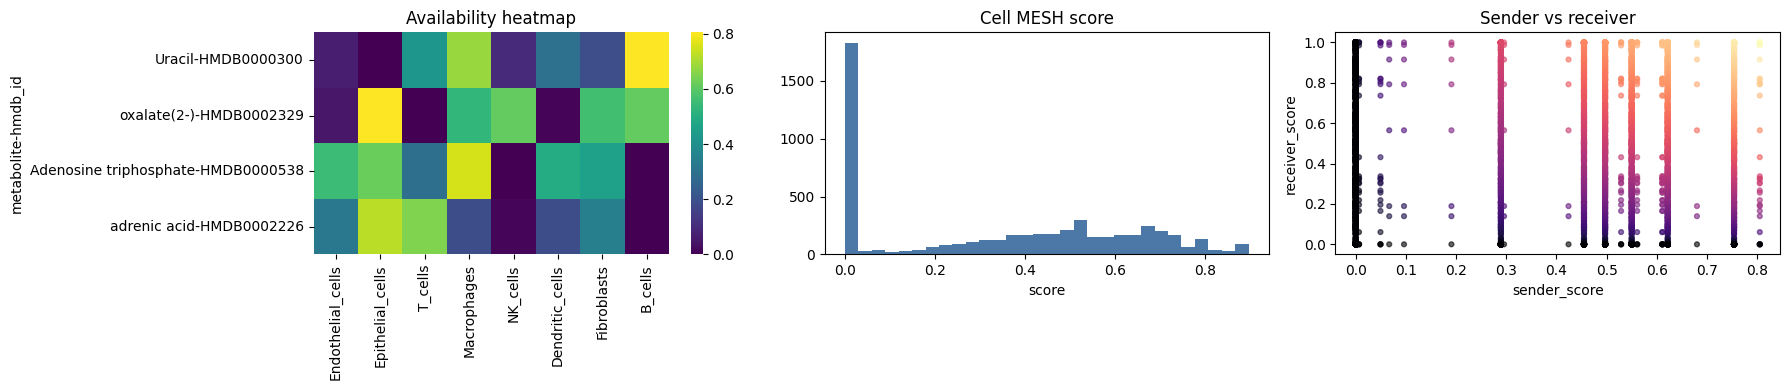

PASS visualization


In [18]:
# 可视化: availability 热图, score 分布直方图, 事件散点图
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
heat = availability.head(min(20, len(availability)))
if sns is not None:
    sns.heatmap(heat, ax=axes[0], cmap='viridis')
else:
    axes[0].imshow(heat.values, aspect='auto', cmap='viridis')
axes[0].set_title('Availability heatmap')

axes[1].hist(events['cell_mesh_score'], bins=30, color='#4C78A8')
axes[1].set_title('Cell MESH score')
axes[1].set_xlabel('score')

axes[2].scatter(events['sender_score'], events['receiver_score'], s=12, alpha=0.6, c=events['cell_mesh_score'], cmap='magma')
axes[2].set_title('Sender vs receiver')
axes[2].set_xlabel('sender_score')
axes[2].set_ylabel('receiver_score')
plt.tight_layout()
plt.show()
print('PASS visualization')

## 总结与结论

本 notebook 覆盖 TC-A1~A10 中适合真实数据交互验证的核心断言、TC-B1~B5 与 TC-B9，并包含三类可视化。本次新增：

1. pseudobulk 聚合前后展示与一致性断言；
2. TC-A2 的 P/C/E 标准化输入、手工 availability 与函数输出对比展示；
3. TC-B9 的自定义参数输入、手工 availability 与函数输出对比，以及默认参数/自定义参数结果对比展示。

置换检验范围、空先验、保存加载等更适合自动化 CI 的用例见 `tests/test_cellmesh_comprehensive.py`。
